# Limestone Data Challenge

In [30]:
import matplotlib.pyplot as plt

In [1]:
import typing as t

import pandas as pd
import numpy as np

def submit_answer_1(index_formulas: pd.DataFrame) -> None:
    from pandas.api.types import is_float_dtype

    assert sorted(index_formulas.columns) == sorted(["index_col", "constituent_col", "coef"])
    assert is_float_dtype(index_formulas["coef"].dtype)
    assert np.all(index_formulas["coef"] >= 0)

    COLUMNS = [f"col_{i:02d}" for i in range(53)]
    for (ic, cc) in zip(
        index_formulas["index_col"],
        index_formulas["constituent_col"],
    ):
        assert isinstance(ic, str)
        assert isinstance(cc, str)
        assert ic != cc
        assert ic in COLUMNS
        assert cc in COLUMNS

    index_formulas.to_csv(
        "modelling_prices.submission.1.csv",
        index=False
    )

### Workspace

In [11]:
DF = pd.read_csv("limestone_data_challenge_2026.data.csv")
DF = DF.set_index(keys="time")

DF.head()

,col_00,col_01,col_02,col_03,col_04,col_05,col_06,col_07,col_08,col_09,...,col_43,col_44,col_45,col_46,col_47,col_48,col_49,col_50,col_51,col_52
time,,,,,,,,,,,,,,,,,,,,,
0,120.138568,111.692124,110.158297,NaN,120.151012,120.181427,NaN,119.740662,NaN,119.977510,...,119.940305,NaN,132.272741,121.768336,NaN,NaN,109.859416,117.808491,119.703005,129.671178
1,121.096957,116.345227,111.709693,NaN,121.626153,121.726396,116.393623,118.050353,123.850491,119.548152,...,123.738967,NaN,NaN,121.896705,NaN,122.699758,110.518188,NaN,NaN,NaN
2,121.377886,NaN,122.153833,118.841414,120.956851,115.415875,124.882967,114.971317,NaN,124.618823,...,125.648662,112.937734,119.998389,116.053638,NaN,118.439899,111.880012,119.799799,120.144533,129.001756
3,NaN,126.247280,127.163454,NaN,119.960063,121.063165,NaN,112.059290,115.168068,NaN,...,NaN,117.205598,115.513093,NaN,124.213788,NaN,NaN,121.112225,122.093434,NaN
4,NaN,120.515769,NaN,116.856146,120.671093,118.978446,NaN,113.936539,116.821607,126.453764,...,127.848139,119.035464,117.431307,NaN,123.244609,120.140786,NaN,122.716514,NaN,126.796467


## Understanding the distribution of Nans:

It would be prudcent to understand if only prices hae NaN values or indexes have NaN values too, we should look at the ditribution of NaNs amongst columns to first of all understand the data

In [ ]:
# total NaNs in the data
total_nans = DF.isna().sum().sum()
print(f"Total NaN ={total_nans}")

#30-60% NaNs

#Nans per column of data 
columns_all_defined = DF.isna().sum().eq(0).sum()
print(columns_all_defined)

Total NaN =94470
0


So quite clearly all columns have NaN values including both prices and index data even though the question didn't explictly state this, there was ambiguity about what smudged "prices" was referring to be it is quite claer now that his was referring to both index prices and the actual prices of the columns.

### Understanding how NaNs are distributed in columns 

<Axes: >

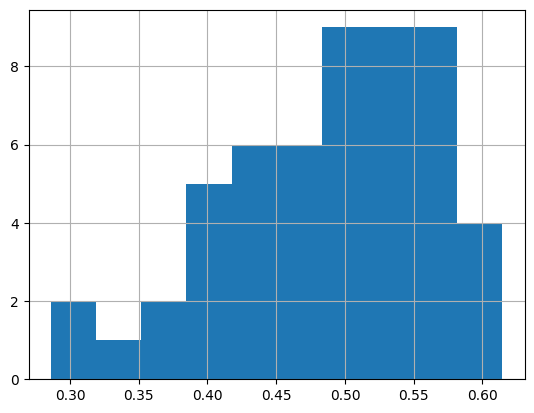

In [28]:
percent_undefined = DF.isna().sum()/len(DF.index)
percent_undefined.hist()

Quite clearly the data is extremely sparse with many columns having a range oof 0.30-0.60 of their data missing 

### Is data missing in contiguous blocks within columns or is it randomly missing? 

This has secondary impacts for inference when we build our trading strategies and may also inform some other aspects of our analysis. 

=== Whole dataset ===
Share of (row, column) cells missing: 0.4883
NAs per row (how many series missing on the same day): min=10, median=26, max=43


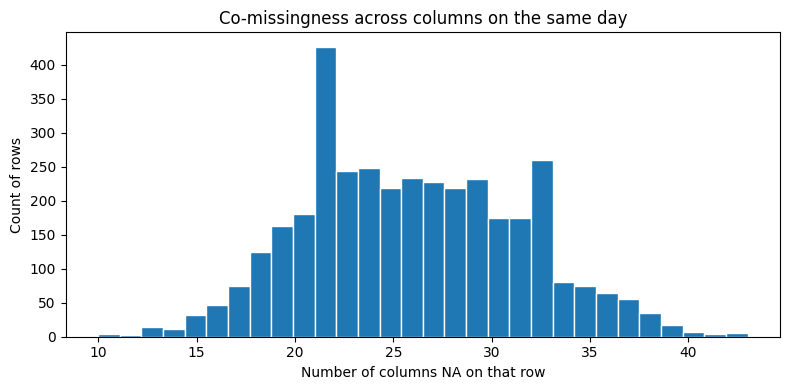


Pairwise correlation of missingness indicators (off-diagonal): median=0.020, mean=0.026
(Higher values → missingness more aligned in time across series.)


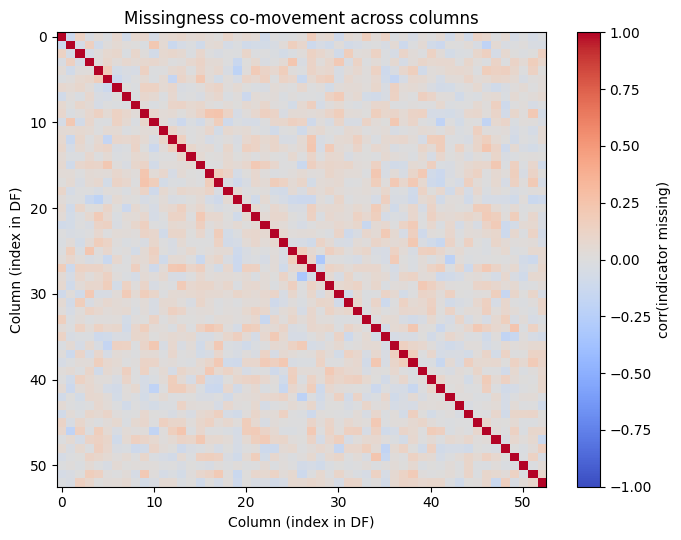


=== Per-column contiguous NaN runs (time-ordered rows) ===
runs_vs_iid = (# observed NA runs) / (expected # runs if each row were NA independently with that column's marginal rate p).
  < 1  → longer blocks / fewer runs than iid (gaps clump in time)
  ~ 1  → similar fragmentation to iid at random
  > 1  → shorter runs / more alternation than iid

Largest mean contiguous NA length (rows ≈ days):
        n_na  n_runs  mean_run  median_run  max_run  runs_vs_iid
column                                                          
col_23  2073     318  6.518868         1.0      331     0.354922
col_51  2242     400  5.605000         1.0      322     0.462301
col_22  2187     411  5.321168         1.0      399     0.468666
col_48  2114     401  5.271820         1.0      404     0.450586
col_05  2108     401  5.256858         1.0      363     0.450111
col_25  2222     430  5.167442         1.0      219     0.494429
col_35  2181     437  4.990847         1.0      266     0.497646
col_03  2120    

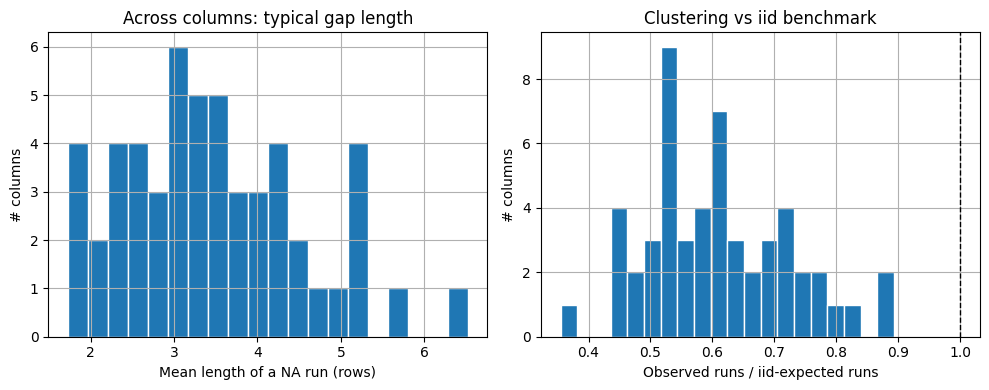

In [29]:
import matplotlib.pyplot as plt

# Row order is treated as the time axis: contiguous NaNs = multi-day gaps in that series.
is_na = DF.isna()
n_rows, n_cols = is_na.shape

print("=== Whole dataset ===")
print(f"Share of (row, column) cells missing: {is_na.to_numpy().mean():.4f}")

na_per_row = is_na.sum(axis=1)
print(
    "NAs per row (how many series missing on the same day): "
    f"min={na_per_row.min()}, median={na_per_row.median():.0f}, max={na_per_row.max()}"
)

na_per_row.plot.hist(bins=30, figsize=(8, 4), edgecolor="white")
plt.xlabel("Number of columns NA on that row")
plt.ylabel("Count of rows")
plt.title("Co-missingness across columns on the same day")
plt.tight_layout()
plt.show()

# Do gaps tend to occur on the same calendar rows across columns?
miss_corr = is_na.astype(float).corr()
triu = np.triu_indices_from(miss_corr, k=1)
off_diag = miss_corr.to_numpy()[triu]
print(
    "\nPairwise correlation of missingness indicators (off-diagonal): "
    f"median={np.median(off_diag):.3f}, mean={off_diag.mean():.3f}"
)
print("(Higher values → missingness more aligned in time across series.)")

plt.figure(figsize=(7, 5.5))
plt.imshow(miss_corr, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="corr(indicator missing)")
plt.xlabel("Column (index in DF)")
plt.ylabel("Column (index in DF)")
plt.title("Missingness co-movement across columns")
plt.tight_layout()
plt.show()


def na_run_lengths(s: pd.Series) -> np.ndarray:
    """Lengths of each contiguous block of NaNs along the time axis."""
    mask = s.isna()
    if not mask.any():
        return np.array([], dtype=int)
    grp = (mask != mask.shift(fill_value=False)).cumsum()
    lengths = []
    for _, block in mask.groupby(grp):
        if bool(block.iloc[0]):
            lengths.append(int(block.sum()))
    return np.asarray(lengths, dtype=int)


rows = []
for col in DF.columns:
    lens = na_run_lengths(DF[col])
    n_na = int(DF[col].isna().sum())
    p = n_na / n_rows
    exp_runs = p + (n_rows - 1) * p * (1 - p) if n_rows else 0.0
    n_runs = len(lens)
    if n_runs == 0:
        rows.append(
            {
                "column": col,
                "n_na": n_na,
                "n_runs": 0,
                "mean_run": np.nan,
                "median_run": np.nan,
                "max_run": np.nan,
                "runs_vs_iid": np.nan,
            }
        )
    else:
        rows.append(
            {
                "column": col,
                "n_na": n_na,
                "n_runs": n_runs,
                "mean_run": float(lens.mean()),
                "median_run": float(np.median(lens)),
                "max_run": int(lens.max()),
                "runs_vs_iid": n_runs / exp_runs if exp_runs > 0 else np.nan,
            }
        )

run_summary = pd.DataFrame(rows).set_index("column").sort_values("mean_run", ascending=False)

print("\n=== Per-column contiguous NaN runs (time-ordered rows) ===")
print(
    "runs_vs_iid = (# observed NA runs) / (expected # runs if each row were NA "
    "independently with that column's marginal rate p).\n"
    "  < 1  → longer blocks / fewer runs than iid (gaps clump in time)\n"
    "  ~ 1  → similar fragmentation to iid at random\n"
    "  > 1  → shorter runs / more alternation than iid\n"
)
print("Largest mean contiguous NA length (rows ≈ days):")
print(run_summary.head(10).to_string())
print("\nSmallest mean contiguous NA length:")
print(run_summary.tail(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
run_summary["mean_run"].dropna().hist(ax=axes[0], bins=20, edgecolor="white")
axes[0].set_xlabel("Mean length of a NA run (rows)")
axes[0].set_ylabel("# columns")
axes[0].set_title("Across columns: typical gap length")

run_summary["runs_vs_iid"].dropna().hist(ax=axes[1], bins=20, edgecolor="white")
axes[1].axvline(1.0, color="k", linestyle="--", linewidth=1)
axes[1].set_xlabel("Observed runs / iid-expected runs")
axes[1].set_ylabel("# columns")
axes[1].set_title("Clustering vs iid benchmark")
plt.tight_layout()
plt.show()


## Understanding the distribution of prices

For each of the columns it would be great to see how different prices may evolve through time to see if there are any outliers when considering indexes vs farmers, and to potentially see how correlated prices from farmers are. Do they in general move together, or might there be quite a bit of variance. 


There might be several different views to get a perspective on this so let's plot a variety of different views to understand pricing dynamics in the market through time

### Average prices per index and farmer

count     53.000000
mean     162.467069
std        2.662272
min      156.835329
25%      160.016682
50%      162.699909
75%      164.269494
max      167.338368
dtype: float64

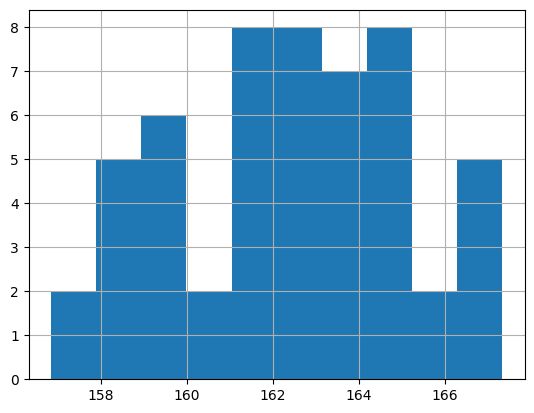

In [ ]:
price_means = DF.mean()
price_means.hist()
price_means.describe()

### Average price over time 

<Axes: xlabel='time'>

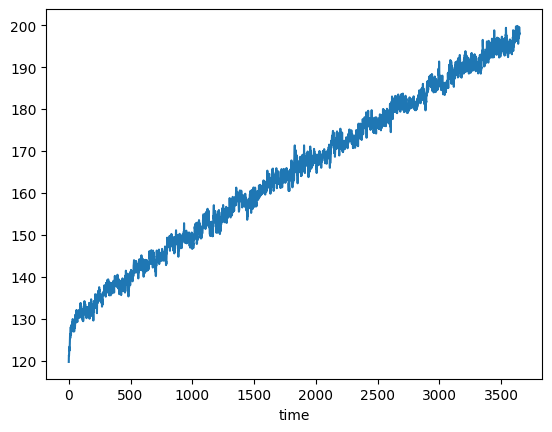

In [25]:
prices_over_time = DF.mean(axis=1)
prices_over_time.plot()

The time series of prices looks to be generally an increasing trend of prices, futhermore it looks like it's mean reverting to a general trend. It looks like the times series of the average price would be stationary once differenced with a linear model against time. This may inform our trading strategy, although we need to be careful not to overfit the data.

### Individual prices over this time

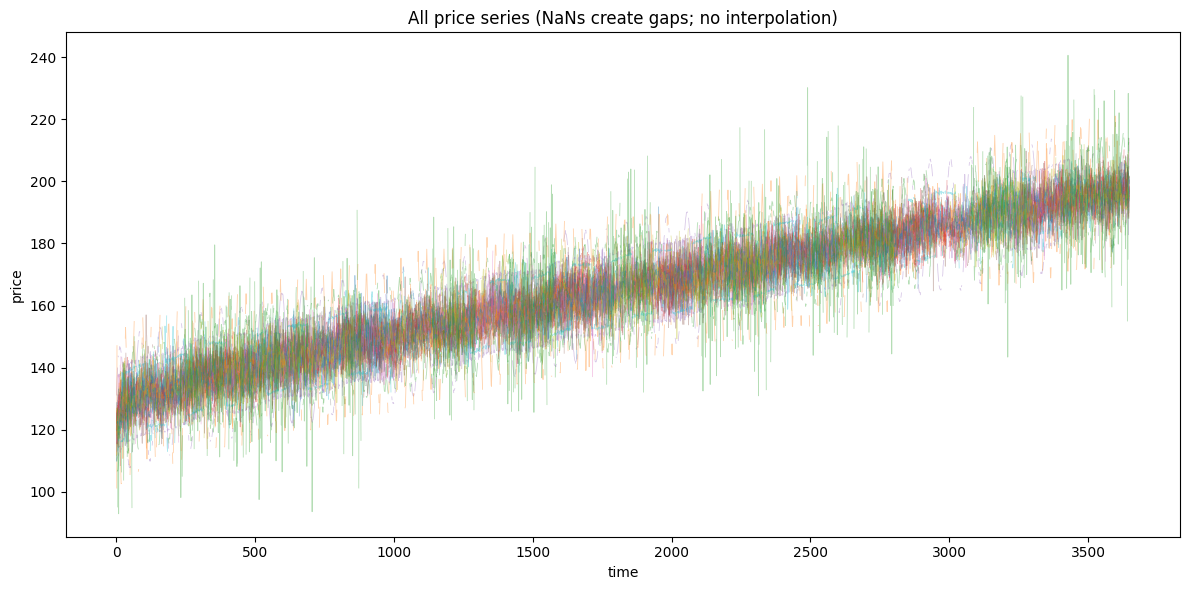

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))

for col in DF.columns:
    ax.plot(DF.index, DF[col], linewidth=0.6, alpha=0.35)

ax.set_xlabel("time")
ax.set_ylabel("price")
ax.set_title("All price series (NaNs create gaps; no interpolation)")
plt.tight_layout()
plt.show()

# PCA analysis of time series data

In [ ]:
import typing as t
import pandas as pd


def placeholder_example_solution_for_format() -> pd.DataFrame:
    df = pd.read_csv("limestone_data_challenge_2026.data.csv")
    answer_to_validate_format = pd.DataFrame(
        {
            "index_col": ["col_00", "col_00"],
            "constituent_col": ["col_01", "col_02"],
            "coef": [0.5, 0.5],
        }
    )
    return answer_to_validate_format


def our_solution() -> pd.DataFrame:
    answer_to_validate_format = pd.DataFrame(
        {
            "index_col": ["col_00", "col_00"],
            "constituent_col": ["col_01", "col_02"],
            "coef": [0.5, 0.5],
        }
    )
    return answer_to_validate_format


submit_answer_1(placeholder_example_solution_for_format())  # You must submit your own final answer.